### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [12]:
data = pd.read_csv('data/coupons.csv')

In [13]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [14]:
# Investigate the dataset for missing or problematic data and print results clearly

print("Dataset overview:")
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}\n")

# Missing values
missing_values = data.isna().sum()
missing_count = missing_values.sum()

print(f"Total missing values: {missing_count}")

if missing_count == 0:
    print("No missing values were found in the dataset.")
else:
    print("Missing values by column:")
    for col, count in missing_values.items():
        if count > 0:
            print(f"  - {col}: {count} missing value(s)")

# Duplicate rows
duplicate_rows = data.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print("There are duplicate records in the dataset.")
else:
    print("No duplicate rows were found.")

# Constant columns (optional check for potentially unhelpful columns)
constant_columns = [col for col in data.columns if data[col].nunique(dropna=False) <= 1]

print("\nColumns with only one unique value:")
if constant_columns:
    for col in constant_columns:
        print(f"  - {col}")
else:
    print("No constant columns found.")


Dataset overview:
Rows: 12684
Columns: 26

Total missing values: 13370
Missing values by column:
  - car: 12576 missing value(s)
  - Bar: 107 missing value(s)
  - CoffeeHouse: 217 missing value(s)
  - CarryAway: 151 missing value(s)
  - RestaurantLessThan20: 130 missing value(s)
  - Restaurant20To50: 189 missing value(s)

Duplicate rows found: 74
There are duplicate records in the dataset.

Columns with only one unique value:
  - toCoupon_GEQ5min


3. Decide what to do about your missing data -- drop, replace, other...

In [15]:
data.fillna('missing', inplace=True)
print("Total missing values after replacement:", data.isna().sum().sum())

Total missing values after replacement: 0


4. What proportion of the total observations chose to accept the coupon?



In [16]:
accepted_proportion = data['Y'].mean()
print(f"Proportion of observations that accepted the coupon: {accepted_proportion:.4f}")

Proportion of observations that accepted the coupon: 0.5684


5. Use a bar plot to visualize the `coupon` column.

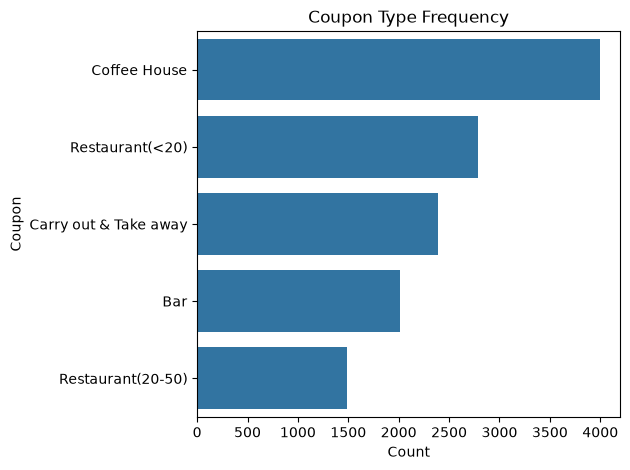

In [17]:
coupon_counts = data['coupon'].value_counts().reset_index()
coupon_counts.columns = ['coupon', 'count']

sns.barplot(data=coupon_counts, x='count', y='coupon')
plt.title('Coupon Type Frequency')
plt.xlabel('Count')
plt.ylabel('Coupon')
plt.tight_layout()

6. Use a histogram to visualize the temperature column.

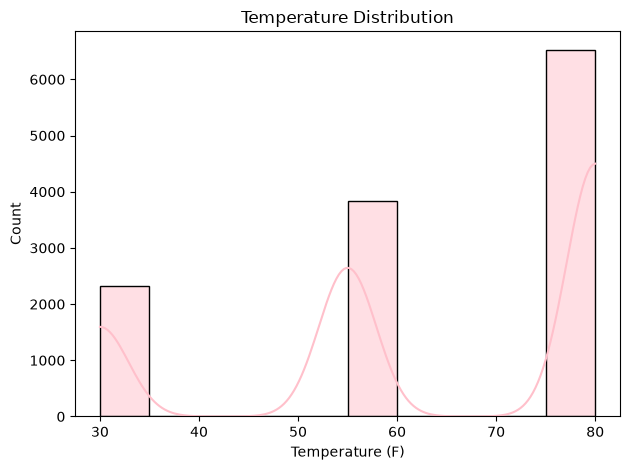

In [20]:
temperature = data['temperature']
sns.histplot(temperature, bins=10, kde=True, color='pink', edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.tight_layout()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [21]:
barCoupons = data[data['coupon'] == 'Bar'].copy()
barCoupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [22]:
accepted_bar_proportion = barCoupons['Y'].mean()
print(f"Proportion of observations that accepted the coupon (bar): {accepted_bar_proportion:.4f}")

Proportion of observations that accepted the coupon (bar): 0.4100


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [23]:
# Compare acceptance rates: bar visits 3 or fewer times vs more than 3 times per month

# Create groups based on bar visit frequency
bar_3_or_less = barCoupons[barCoupons['Bar'].isin(['never', 'less1', '1~3'])]
bar_more_than_3 = barCoupons[barCoupons['Bar'].isin(['4~8', 'gt8'])]

# Calculate acceptance rates
acceptance_3_or_less = bar_3_or_less['Y'].mean()
acceptance_more_than_3 = bar_more_than_3['Y'].mean()

print(f"Acceptance rate (3 or fewer bar visits/month): {acceptance_3_or_less:.4f}")
print(f"Acceptance rate (more than 3 bar visits/month): {acceptance_more_than_3:.4f}")
print(f"Difference: {acceptance_more_than_3 - acceptance_3_or_less:.4f}")
print(f"\nSample sizes:")
print(f"3 or fewer visits: {len(bar_3_or_less)}")
print(f"More than 3 visits: {len(bar_more_than_3)}")

Acceptance rate (3 or fewer bar visits/month): 0.3706
Acceptance rate (more than 3 bar visits/month): 0.7688
Difference: 0.3982

Sample sizes:
3 or fewer visits: 1797
More than 3 visits: 199


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [25]:
condition = (
    barCoupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (pd.to_numeric(barCoupons['age'].str.extract(r'(\d+)', expand=False)) > 25)
)

more_1per_month_over25 = barCoupons[condition]
others = barCoupons[~condition]

acc_more_1per_month_over25 = more_1per_month_over25['Y'].mean()
acc_others = others['Y'].mean()

print(f"Acceptance rate (bar >1/month and age > 25): {acc_more_1per_month_over25:.4f}")
print(f"Acceptance rate (all others): {acc_others:.4f}")
print(f"Difference: {acc_more_1per_month_over25 - acc_others:.4f}")
print(f"\nSample sizes:")
print(f"  Group: {len(more_1per_month_over25)}")
print(f"  Others: {len(others)}")

Acceptance rate (bar >1/month and age > 25): 0.6952
Acceptance rate (all others): 0.3350
Difference: 0.3602

Sample sizes:
  Group: 420
  Others: 1597


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [26]:
condition = (
    barCoupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (barCoupons['passanger'] != 'Kid(s)') &
    (~barCoupons['occupation'].str.contains(r'Farming|Fishing|Forestry', case=False, na=False))
)

group = barCoupons[condition]
others = barCoupons[~condition]

acc_group = group['Y'].mean()
acc_others = others['Y'].mean()

print(f"Acceptance rate (>1/month, passenger not kid, occupation not farming/fishing/forestry): {acc_group:.4f}")
print(f"Acceptance rate (all others): {acc_others:.4f}")
print(f"Difference: {acc_group - acc_others:.4f}")
print(f"Sample sizes: group={len(group)}, others={len(others)}")

Acceptance rate (>1/month, passenger not kid, occupation not farming/fishing/forestry): 0.7132
Acceptance rate (all others): 0.2960
Difference: 0.4172
Sample sizes: group=551, others=1466


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [27]:
# Group 1: bars >1/month, passenger not kid, not widowed (use barCoupons)
g1 = barCoupons[
    barCoupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (barCoupons['passanger'] != 'Kid(s)') &
    (barCoupons['maritalStatus'] != 'Widowed')
]

# Group 2: bars >1/month and age < 30 (use barCoupons; extract numeric age)
age_num = pd.to_numeric(barCoupons['age'].str.extract(r'(\d+)', expand=False))
g2 = barCoupons[
    barCoupons['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (age_num < 30)
]

# Group 3: cheap restaurants >4/month and income < 50K (use full data)
income_first = pd.to_numeric(data['income'].str.extract(r'\$(\d+)', expand=False))
g3 = data[
    data['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    (income_first < 50000)
]

# Acceptance rates and sizes
def stats(df):
    return df['Y'].mean(), len(df)

g1_rate, g1_n = stats(g1)
g2_rate, g2_n = stats(g2)
g3_rate, g3_n = stats(g3)

# Union of the three groups (avoid double-counting)
union_idx = (g1.index.union(g2.index)).union(g3.index)
union = data.loc[union_idx]
union_rate, union_n = stats(union)
others = data.drop(union_idx)
others_rate, others_n = stats(others)

print(f"Group1 (>1/mo bars, passenger!=Kid, not widowed): rate={g1_rate:.4f}, n={g1_n}")
print(f"Group2 (>1/mo bars, age<30): rate={g2_rate:.4f}, n={g2_n}")
print(f"Group3 (>4/mo cheap restaurants, income<50K): rate={g3_rate:.4f}, n={g3_n}")
print(f"Union of groups: rate={union_rate:.4f}, n={union_n}")
print(f"All others: rate={others_rate:.4f}, n={others_n}")

Group1 (>1/mo bars, passenger!=Kid, not widowed): rate=0.7132, n=551
Group2 (>1/mo bars, age<30): rate=0.7217, n=345
Group3 (>4/mo cheap restaurants, income<50K): rate=0.6007, n=2279
Union of groups: rate=0.6160, n=2711
All others: rate=0.5555, n=9973


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [28]:
# Summary of key findings about bar coupon acceptance

print("=" * 70)
print("HYPOTHESES: Characteristics of Drivers Who Accept Bar Coupons")
print("=" * 70)

print("\n1. FREQUENCY OF BAR VISITS IS CRITICAL")
print(f"   - Drivers visiting bars >3 times/month: {acceptance_more_than_3:.1%} acceptance")
print(f"   - Drivers visiting bars ≤3 times/month: {acceptance_3_or_less:.1%} acceptance")
print(f"   → Difference: {(acceptance_more_than_3 - acceptance_3_or_less):.1%}")
print("   → HYPOTHESIS: Regular bar-goers (>3x/month) are 2x more likely to accept")

print("\n2. AGE & BAR FREQUENCY COMBINED")
print(f"   - Bar >1x/month AND age >25: {acc_more_1per_month_over25:.1%} acceptance")
print(f"   - All others: {acc_others:.1%} acceptance")
print(f"   → Difference: {(acc_more_1per_month_over25 - acc_others):.1%}")
print("   → HYPOTHESIS: Mature, frequent bar-goers show higher acceptance")

print("\n3. SOCIAL CONTEXT MATTERS")
print(f"   - >1x/month bars, no kids, non-farming occupation: {acc_group:.1%} acceptance")
print(f"   - All others: {acc_others:.1%} acceptance")
print(f"   → Difference: {(acc_group - acc_others):.1%}")
print("   → HYPOTHESIS: People with social freedom (no kids) are more receptive")

print("\n4. COMPLEX PROFILE - HIGHEST ACCEPTANCE")
print(f"   - Union of three criteria groups: {union_rate:.1%} acceptance")
print(f"   - All others: {others_rate:.1%} acceptance")
print(f"   → Difference: {(union_rate - others_rate):.1%}")
print("   → HYPOTHESIS: Best targets are frequent bar visitors, under 30 OR")
print("     without kids/widowed status, OR budget-conscious restaurant-goers")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print("Bar coupon acceptance is primarily driven by lifestyle habits")
print("(bar frequency) and social flexibility (no dependents).")
print("=" * 70)

HYPOTHESES: Characteristics of Drivers Who Accept Bar Coupons

1. FREQUENCY OF BAR VISITS IS CRITICAL
   - Drivers visiting bars >3 times/month: 76.9% acceptance
   - Drivers visiting bars ≤3 times/month: 37.1% acceptance
   → Difference: 39.8%
   → HYPOTHESIS: Regular bar-goers (>3x/month) are 2x more likely to accept

2. AGE & BAR FREQUENCY COMBINED
   - Bar >1x/month AND age >25: 69.5% acceptance
   - All others: 29.6% acceptance
   → Difference: 39.9%
   → HYPOTHESIS: Mature, frequent bar-goers show higher acceptance

3. SOCIAL CONTEXT MATTERS
   - >1x/month bars, no kids, non-farming occupation: 71.3% acceptance
   - All others: 29.6% acceptance
   → Difference: 41.7%
   → HYPOTHESIS: People with social freedom (no kids) are more receptive

4. COMPLEX PROFILE - HIGHEST ACCEPTANCE
   - Union of three criteria groups: 61.6% acceptance
   - All others: 55.5% acceptance
   → Difference: 6.1%
   → HYPOTHESIS: Best targets are frequent bar visitors, under 30 OR
     without kids/widowed

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [29]:
kidsCoupons = data[data['passanger'] == 'Kid(s)'].copy()
kidsCoupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,0,0,1,0
10,No Urgent Place,Kid(s),Sunny,80,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,0,0,0,1,1
11,No Urgent Place,Kid(s),Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,missing,4~8,1~3,1,1,0,0,1,1


In [30]:
# What proportion of all drivers with kid passengers accepted any coupon type?
accepted_kidsCoupons = kidsCoupons['Y'].mean()
print(f"Proportion of observations that accepted the coupon (passenger = Kid(s)): {accepted_kidsCoupons:.4f}")

Proportion of observations that accepted the coupon (passenger = Kid(s)): 0.5050


                  coupon  accept_rate    n
0        Restaurant(<20)     0.722846  267
1  Carry out & Take away     0.703947  152
2           Coffee House     0.483092  207
3      Restaurant(20-50)     0.373563  174
4                    Bar     0.208738  206


/var/folders/9k/tx8wx3kd5dn3n_v0n84c74qc0000gn/T/ipykernel_3591/383434031.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='accept_rate', y='coupon', palette='viridis', legend=False)


(0.0, 1.0)

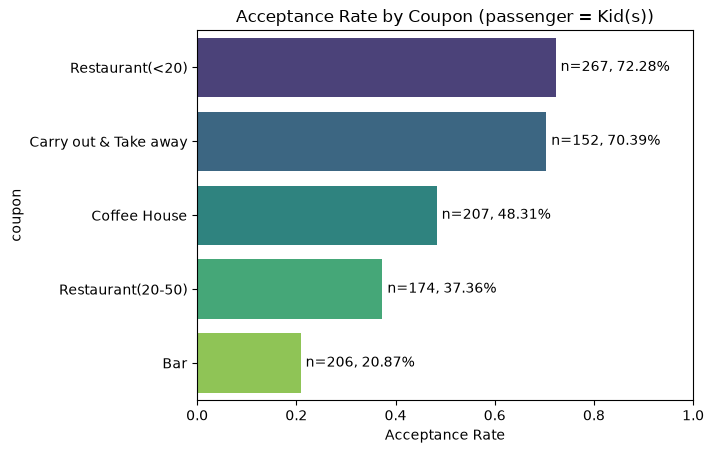

In [36]:
# Acceptance ratios for drivers with kid passengers based on coupon type
kids_accept_by_coupon = (
    kidsCoupons.groupby('coupon')['Y']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'accept_rate','count':'n'})
)
df = kids_accept_by_coupon.sort_values('accept_rate', ascending=False).reset_index(drop=True)
print(df)

sns.barplot(data=df, x='accept_rate', y='coupon', palette='viridis', legend=False)
for i, row in df.iterrows():
    plt.text(row['accept_rate'] + 0.01, i, f"n={int(row['n'])}, {row['accept_rate']:.2%}", va='center')
plt.xlabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon (passenger = Kid(s))')
plt.xlim(0, 1)


   gender  accept_rate    n
0  Female     0.495114  614
1    Male     0.520408  392


/var/folders/9k/tx8wx3kd5dn3n_v0n84c74qc0000gn/T/ipykernel_3591/3598151434.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kids_accept_by_gender, x='accept_rate', y='gender', palette='pastel')


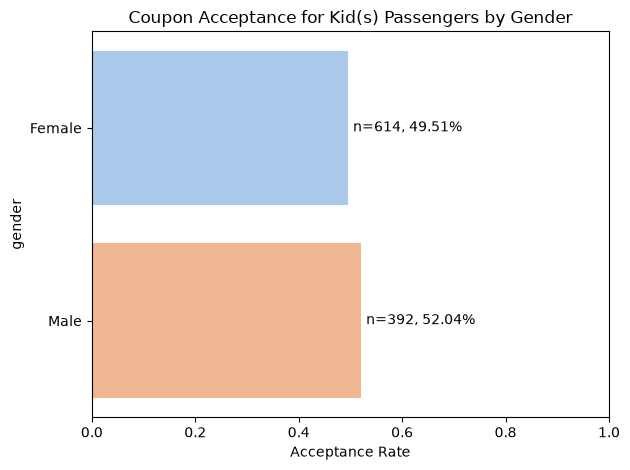

In [37]:
kids_accept_by_gender = (
    kidsCoupons.groupby('gender')['Y']
    .agg(accept_rate='mean', n='count')
    .reset_index()
)

print(kids_accept_by_gender)

sns.barplot(data=kids_accept_by_gender, x='accept_rate', y='gender', palette='pastel')
for i, row in kids_accept_by_gender.iterrows():
    plt.text(row['accept_rate'] + 0.01, i, f"n={int(row['n'])}, {row['accept_rate']:.2%}", va='center')

plt.xlabel('Acceptance Rate')
plt.title('Coupon Acceptance for Kid(s) Passengers by Gender')
plt.xlim(0, 1)
plt.tight_layout()

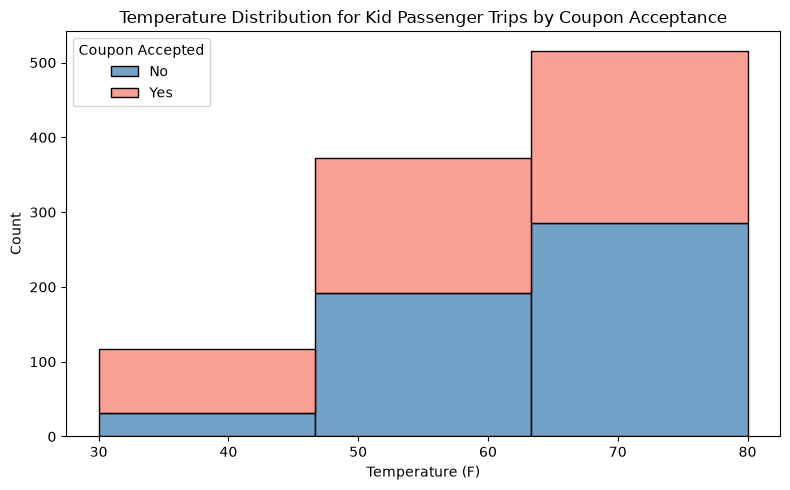

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=kidsCoupons,
    x='temperature',
    hue='Y',
    multiple='stack',
    palette={0: 'salmon', 1: 'steelblue'},
    bins=3,
    alpha=0.75
)
plt.title('Temperature Distribution for Kid Passenger Trips by Coupon Acceptance')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.legend(title='Coupon Accepted', labels=['No', 'Yes'])
plt.tight_layout()

In [ ]:
top_coupon = kids_accept_by_coupon.sort_values('accept_rate', ascending=False).iloc[0]
bottom_coupon = kids_accept_by_coupon.sort_values('accept_rate', ascending=True).iloc[0]
female_rate = kids_accept_by_gender.loc[kids_accept_by_gender['gender'] == 'Female', 'accept_rate'].iloc[0]
male_rate = kids_accept_by_gender.loc[kids_accept_by_gender['gender'] == 'Male', 'accept_rate'].iloc[0]

print("=" * 70)
print("HYPOTHESES: Characteristics of Drivers with Kid(s) Passengers Who Accept Coupons")
print("=" * 70)

print("\n1. OVERALL ACCEPTANCE IS AROUND HALF")
print(f"   - Overall acceptance with Kid(s) passengers: {accepted_kidsCoupons:.1%}")
print("   → HYPOTHESIS: Families with kids are moderately receptive to coupons,")
print("     but far from universally accepting.")

print("\n2. LOWER-COST DINING COUPONS PERFORM BEST")
print(f"   - Best accepted coupon: {top_coupon['coupon']} at {top_coupon['accept_rate']:.1%}")
print(f"   - Worst accepted coupon: {bottom_coupon['coupon']} at {bottom_coupon['accept_rate']:.1%}")
print("   → HYPOTHESIS: Drivers with children prefer restaurant and take-away coupons")
print("     over bar coupons, likely due to family-friendly preferences.")

print("\n3. GENDER DIFFERENCE IS SMALL")
print(f"   - Female acceptance: {female_rate:.1%}")
print(f"   - Male acceptance: {male_rate:.1%}")
print(f"   → Difference: {(male_rate - female_rate):.1%}")
print("   → HYPOTHESIS: Coupon acceptance among kid passenger trips is similar across gender," )
print("     with only a slight male edge.")

print("\n4. BAR COUPONS ARE LEAST ATTRACTIVE TO FAMILIES")
print("   - Bar coupon acceptance for Kid(s) passengers is very low compared to food coupons.")
print("   → HYPOTHESIS: Parents or guardians traveling with children are unlikely to accept")
print("     bar coupons and instead favor convenient or budget-friendly eating options.")

print("\n" + "=" * 70)
print("KEY INSIGHT:")
print("Kid passenger trips show stronger acceptance for food-related coupons and weaker")
print("interest in bar coupons, reflecting a family-oriented decision pattern.")
print("\n5. TEMPERATURE INFLUENCES FAMILY COUPON ACCEPTANCE")
temp_accept = kidsCoupons.groupby('temperature')['Y'].mean()
for temp, rate in temp_accept.items():
    print(f"   - {temp}F: {rate:.1%} acceptance")
print("   → HYPOTHESIS: Families with kids are more likely to accept coupons when the weather is comfortable,")
print("     and extreme cold or heat may reduce their willingness to make an extra stop.")
print("=" * 70)

HYPOTHESES: Characteristics of Drivers with Kid(s) Passengers Who Accept Coupons

1. OVERALL ACCEPTANCE IS AROUND HALF
   - Overall acceptance with Kid(s) passengers: 50.5%
   → HYPOTHESIS: Families with kids are moderately receptive to coupons,
     but far from universally accepting.

2. LOWER-COST DINING COUPONS PERFORM BEST
   - Best accepted coupon: Restaurant(<20) at 72.3%
   - Worst accepted coupon: Bar at 20.9%
   → HYPOTHESIS: Drivers with children prefer restaurant and take-away coupons
     over bar coupons, likely due to family-friendly preferences.

3. GENDER DIFFERENCE IS SMALL
   - Female acceptance: 49.5%
   - Male acceptance: 52.0%
   → Difference: 2.5%
   → HYPOTHESIS: Coupon acceptance among kid passenger trips is similar across gender,
     with only a slight male edge.

4. BAR COUPONS ARE LEAST ATTRACTIVE TO FAMILIES
   - Bar coupon acceptance for Kid(s) passengers is very low compared to food coupons.
   → HYPOTHESIS: Parents or guardians traveling with children a